In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost

ERROR: Could not find a version that satisfies the requirement scikit-learn (from versions: none)
ERROR: No matching distribution found for scikit-learn


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [13]:
np.random.seed(42)

n = 5000

data = pd.DataFrame({
    "TransactionID": range(1, n+1),
    "TransactionAmount": np.random.uniform(10, 2000, n),
    "TransactionTime": np.random.randint(0, 24, n),
    "UserAge": np.random.randint(18, 70, n),
    "UserLocation": np.random.choice(["USA","India","UK","Germany"], n),
    "DeviceType": np.random.choice(["Mobile","Desktop","Tablet"], n),
    "PaymentMethod": np.random.choice(["CreditCard","DebitCard","PayPal","Crypto"], n),
    "AccountAge": np.random.randint(10, 2000, n),
    "TransactionFrequency": np.random.randint(1, 50, n),
    "IsInternational": np.random.choice([0,1], n),
    "PreviousFraudHistory": np.random.choice([0,1], n, p=[0.9,0.1])
})

data["IsFraud"] = np.random.choice([0,1], n, p=[0.95,0.05])

data.head()

,TransactionID,TransactionAmount,TransactionTime,UserAge,UserLocation,DeviceType,PaymentMethod,AccountAge,TransactionFrequency,IsInternational,PreviousFraudHistory,IsFraud
0,1,755.334837,18,25,India,Tablet,DebitCard,1216,33,1,0,1
1,2,1901.921470,7,24,USA,Desktop,DebitCard,1402,44,0,0,0
2,3,1466.667944,6,51,UK,Mobile,CreditCard,710,3,0,0,0
3,4,1201.330384,15,61,India,Tablet,DebitCard,22,1,1,0,0
4,5,320.477094,18,31,USA,Desktop,CreditCard,1592,36,1,0,0


In [14]:
le = LabelEncoder()

data["UserLocation"] = le.fit_transform(data["UserLocation"])
data["DeviceType"] = le.fit_transform(data["DeviceType"])
data["PaymentMethod"] = le.fit_transform(data["PaymentMethod"])

In [15]:
X = data.drop(["TransactionID","IsFraud"], axis=1)
y = data["IsFraud"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

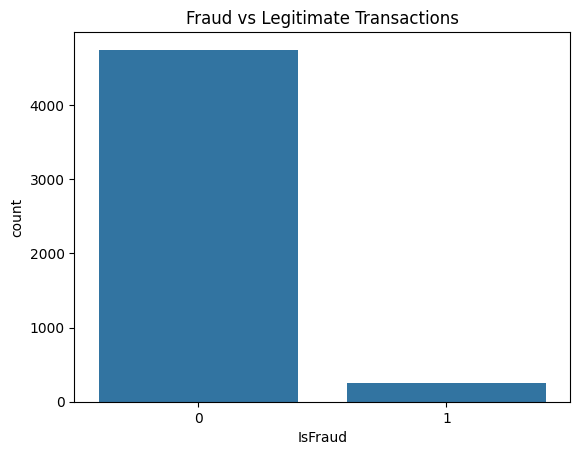

In [19]:
sns.countplot(x=data["IsFraud"])
plt.title("Fraud vs Legitimate Transactions")
plt.show()

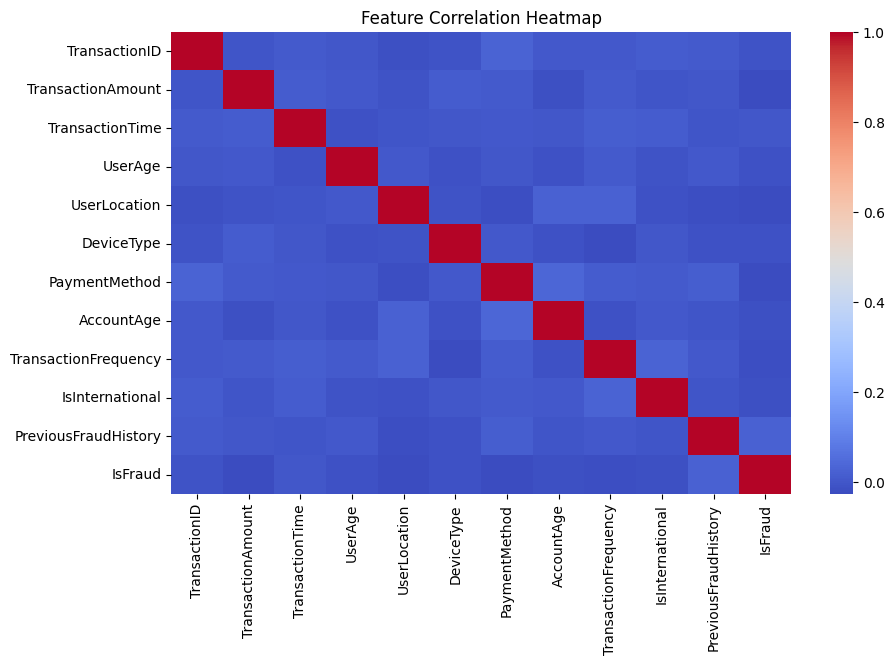

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

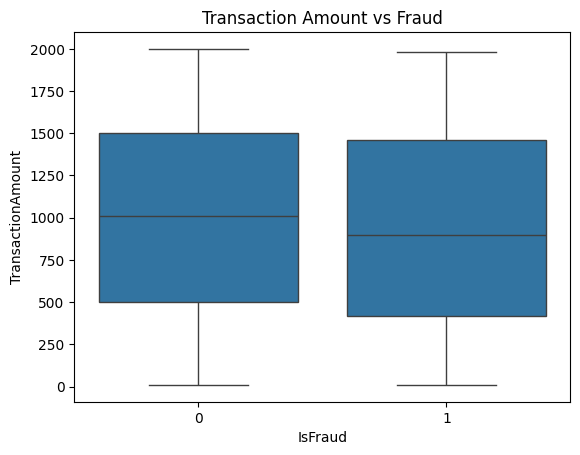

In [21]:
sns.boxplot(x=data["IsFraud"], y=data["TransactionAmount"])
plt.title("Transaction Amount vs Fraud")
plt.show()

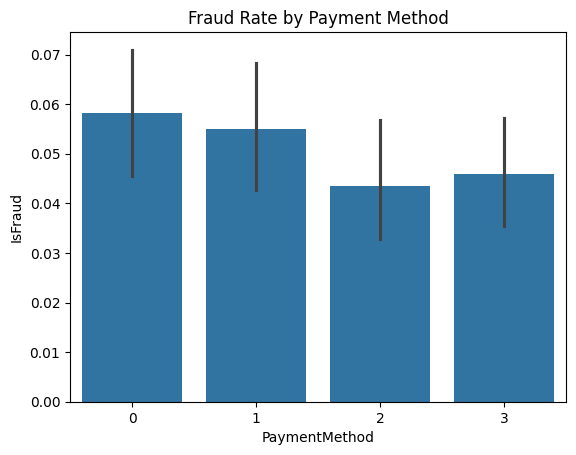

In [22]:
sns.barplot(x="PaymentMethod", y="IsFraud", data=data)
plt.title("Fraud Rate by Payment Method")
plt.show()

In [23]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

In [24]:
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

In [25]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

c:\Users\jenda nithin patil\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:55:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [26]:
def evaluate(y_true, y_pred, prob):

    print("Accuracy:", accuracy_score(y_true,y_pred))
    print("Precision:", precision_score(y_true,y_pred))
    print("Recall:", recall_score(y_true,y_pred))
    print("F1 Score:", f1_score(y_true,y_pred))
    print("ROC-AUC:", roc_auc_score(y_true,prob))

    print("\nConfusion Matrix\n")
    print(confusion_matrix(y_true,y_pred))

In [27]:
print("Logistic Regression")
evaluate(y_test, lr_pred, lr_prob)

print("\nRandom Forest")
evaluate(y_test, rf_pred, rf_prob)

print("\nXGBoost")
evaluate(y_test, xgb_pred, xgb_prob)

Logistic Regression
Accuracy: 0.689
Precision: 0.060810810810810814
Recall: 0.35294117647058826
F1 Score: 0.1037463976945245
ROC-AUC: 0.5579247505113742

Confusion Matrix

[[671 278]
 [ 33  18]]

Random Forest
Accuracy: 0.86
Precision: 0.06796116504854369
Recall: 0.13725490196078433
F1 Score: 0.09090909090909091
ROC-AUC: 0.5130994442033927

Confusion Matrix

[[853  96]
 [ 44   7]]

XGBoost
Accuracy: 0.86
Precision: 0.041237113402061855
Recall: 0.0784313725490196
F1 Score: 0.05405405405405406
ROC-AUC: 0.49410111779168997

Confusion Matrix

[[856  93]
 [ 47   4]]


In [28]:
def risk_score(prob):

    score = int(prob * 100)

    if score <= 30:
        category = "Low Risk"
    elif score <= 70:
        category = "Medium Risk"
    else:
        category = "High Risk"

    return score, category

In [29]:
def predict_transaction():

    amount = float(input("Transaction Amount: "))
    payment = int(input("Payment Method (0=CreditCard 1=DebitCard 2=PayPal 3=Crypto): "))
    international = int(input("International (0/1): "))
    freq = int(input("Transaction Frequency: "))
    prev_fraud = int(input("Previous Fraud History (0/1): "))

    sample = np.array([[amount,12,30,1,1,payment,1000,freq,international,prev_fraud]])

    sample = scaler.transform(sample)

    prob = rf.predict_proba(sample)[0][1]

    score, category = risk_score(prob)

    print("\nFraud Probability:", prob)
    print("Risk Score:", score)
    print("Risk Category:", category)

    if category == "High Risk":
        print("⚠️ Recommendation: Block transaction and investigate.")
    elif category == "Medium Risk":
        print("⚠️ Recommendation: Require additional verification.")
    else:
        print("✅ Transaction appears safe.")

In [33]:
predict_transaction()


Fraud Probability: 0.14
Risk Score: 14
Risk Category: Low Risk
✅ Transaction appears safe.


c:\Users\jenda nithin patil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
